In [1]:
import sys
sys.path.append('../../scripts')
import utils as util
import stock_indicators as si
import plot as plot
import text_analyzer
import correlation_analyzer as ca

In [2]:
stockutils = util.StockUtils
preprocesser = util.DataPreprocessor

Load the Data.

In [3]:
data = stockutils.load_stock_data('../../data/Stock Data/AMZN.csv')
data.head(5)

,Ticker,Date,Close,High,Low,Open,Volume
0,AMZN,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,AMZN,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,AMZN,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,AMZN,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,AMZN,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


In [4]:
preprocesser.explore_data(data)

Shape of the data: (3774, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  3774 non-null   object 
 1   Date    3774 non-null   object 
 2   Close   3774 non-null   float64
 3   High    3774 non-null   float64
 4   Low     3774 non-null   float64
 5   Open    3774 non-null   float64
 6   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 206.5+ KB
Info of the data: None


Reorder the columns and keep the ticker symbol.

In [5]:
data = data[['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [6]:
stockutils.index_by_date(data)
data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2009-01-02,AMZN,2.5675,2.7265,2.5535,2.718,145928000
2009-01-05,AMZN,2.7865,2.7870,2.6515,2.703,190196000
2009-01-06,AMZN,2.7275,2.9110,2.6875,2.868,221602000
2009-01-07,AMZN,2.8145,2.8475,2.7675,2.810,158854000
2009-01-08,AMZN,2.7495,2.8660,2.7290,2.858,131558000


In [7]:
data.describe()

,Open,High,Low,Close,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,59.423925,60.116390,58.669489,59.408094,9.185184e+07
std,54.953769,55.610783,54.233978,54.918541,6.057553e+07
min,2.428000,2.505000,2.381500,2.422000,1.762600e+07
25%,12.146625,12.300250,12.042125,12.194500,5.586350e+07
50%,36.322500,36.489000,36.004000,36.359499,7.520600e+07
75%,96.663498,97.750000,95.379747,96.638248,1.086060e+08
max,187.199997,188.654007,184.839493,186.570496,1.166116e+09


In [8]:
plotter = plot.Plot

#### Analysis Indicators with TA-Lib

In [9]:
technical_indicators = si.IndicatorCalculator

In [10]:
technical_indicators.calculate_technical_indicators(data)
data.tail(5)

,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACDSignal,MACD_hist
Date,,,,,,,,,,,,,,
2023-12-22,AMZN,153.770004,154.350006,152.710007,153.419998,29514100,148.578999,141.2430,148.578999,141.2430,64.115558,3.135958,2.873052,0.262905
2023-12-26,AMZN,153.559998,153.979996,153.029999,153.410004,25067200,148.863000,141.7154,148.863000,141.7154,64.085644,3.118650,2.922172,0.196478
2023-12-27,AMZN,153.559998,154.779999,153.119995,153.339996,31434700,149.178500,142.1312,149.178500,142.1312,63.860893,3.063965,2.950530,0.113434
2023-12-28,AMZN,153.720001,154.080002,152.949997,153.380005,27057000,149.531499,142.5694,149.531499,142.5694,63.938728,2.989395,2.958303,0.031092
2023-12-29,AMZN,153.100006,153.889999,151.029999,151.940002,39823200,149.824000,143.0456,149.824000,143.0456,59.012257,2.782032,2.923049,-0.141017


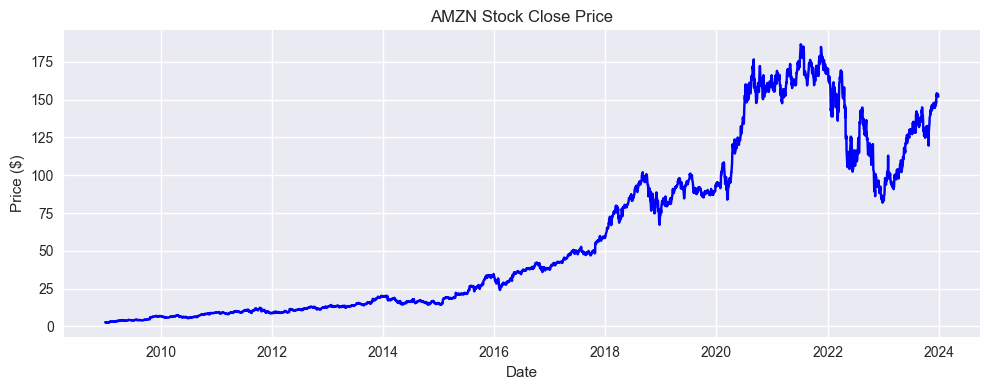

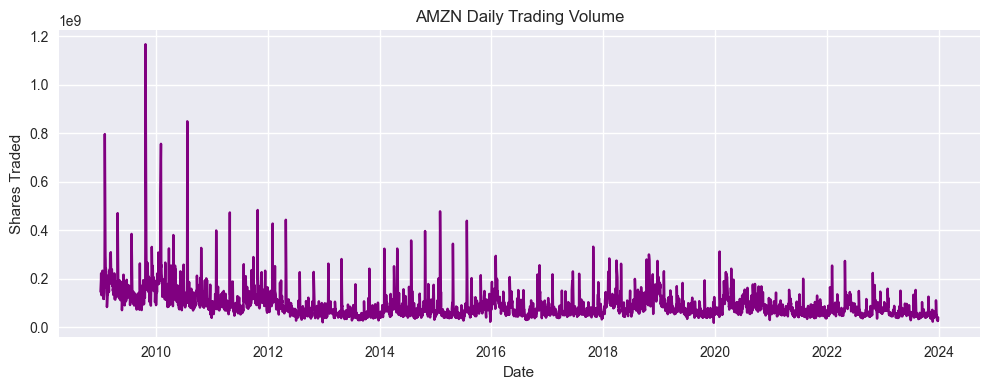

In [11]:
plotter.plot_stock_price(data)

In [12]:
plotter.plot_stock_mva(data)

In [13]:
plotter.plot_ema(data)

In [14]:
plotter.plot_rsi(data)

In [15]:
plotter.plot_macd(data)

### Correlation Analysis

In [16]:
headline_data = util.load_data('../../data/cleaned/cleaned_news_data.csv')

After loading the data, we filter the headlines by stock. And then normalize the dates as we did previously.

In [17]:
headline_data = stockutils.filter_data_by_stock(headline_data, 'AMZN')
preprocesser.convert_date_dtype(headline_data)
headline_data.head(5)

Converted 'date' dtype: datetime64[ns, UTC]


,headline,url,publisher,date,stock
76177,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 17:18:50+00:00,AMZN
76178,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,AMZN
76179,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47+00:00,AMZN
76180,"Hearing Vertical Group Out Positive On Amazon,...",https://www.benzinga.com/analyst-ratings/analy...,Benzinga Newsdesk,2020-06-10 11:20:03+00:00,AMZN
76181,Big Tech Reaches New Record Heights At The Sto...,https://www.benzinga.com/news/20/06/16218615/b...,Neer Varshney,2020-06-10 04:52:01+00:00,AMZN


In [18]:
textanaysis = text_analyzer.TextAnalyzer

Here we only keep the relevant columns for the correlation analysis.

In [19]:
headline_with_sentiment = textanaysis.analyze_headline_sentiment(headline_data)
headline_with_sentiment['date'] = headline_with_sentiment ['date'].dt.date

headlines_with_sentiment= headline_with_sentiment[['date', 'headline', 'stock', 'sentiment', 'sentiment_score']].copy()

In [20]:
combined_data = stockutils.merge_sentiment_with_stock(headlines_with_sentiment, data)
combined_data.head()

,headline,stock,sentiment,sentiment_score,Close,Volume
date,,,,,,
2020-06-10,How Cannabis Company Cannaphyll Is Marketing O...,AMZN,positive,0.1779,132.372498,98920000.0
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,AMZN,positive,0.5574,132.372498,98920000.0
2020-06-10,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AMZN,positive,0.2023,132.372498,98920000.0
2020-06-10,"Hearing Vertical Group Out Positive On Amazon,...",AMZN,positive,0.6486,132.372498,98920000.0
2020-06-10,Big Tech Reaches New Record Heights At The Sto...,AMZN,positive,0.0516,132.372498,98920000.0


Update all columns to be in lowercase.

In [21]:
combined_data_lowercase = stockutils.lowercase_columns(combined_data)
combined_data_lowercase.head(5)

,headline,stock,sentiment,sentiment_score,close,volume
date,,,,,,
2020-06-10,How Cannabis Company Cannaphyll Is Marketing O...,AMZN,positive,0.1779,132.372498,98920000.0
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,AMZN,positive,0.5574,132.372498,98920000.0
2020-06-10,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AMZN,positive,0.2023,132.372498,98920000.0
2020-06-10,"Hearing Vertical Group Out Positive On Amazon,...",AMZN,positive,0.6486,132.372498,98920000.0
2020-06-10,Big Tech Reaches New Record Heights At The Sto...,AMZN,positive,0.0516,132.372498,98920000.0


#### Daily Returns

In [22]:
data_with_daily_returns = technical_indicators.calculate_daily_returns(combined_data_lowercase)
data_with_daily_returns.head()

/Users/hazel/Desktop/Self Study/kiam8/kaim-week-1/notebooks/stocks/../../scripts/stock_indicators.py:47: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,headline,stock,sentiment,sentiment_score,close,volume,daily_returns
date,,,,,,,
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,AMZN,positive,0.5574,132.372498,98920000.0,0.0
2020-06-10,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AMZN,positive,0.2023,132.372498,98920000.0,0.0
2020-06-10,"Hearing Vertical Group Out Positive On Amazon,...",AMZN,positive,0.6486,132.372498,98920000.0,0.0
2020-06-10,Big Tech Reaches New Record Heights At The Sto...,AMZN,positive,0.0516,132.372498,98920000.0,0.0
2020-06-10,"Twitter, Square Will Mark Juneteenth As Holida...",AMZN,positive,0.7096,132.372498,98920000.0,0.0


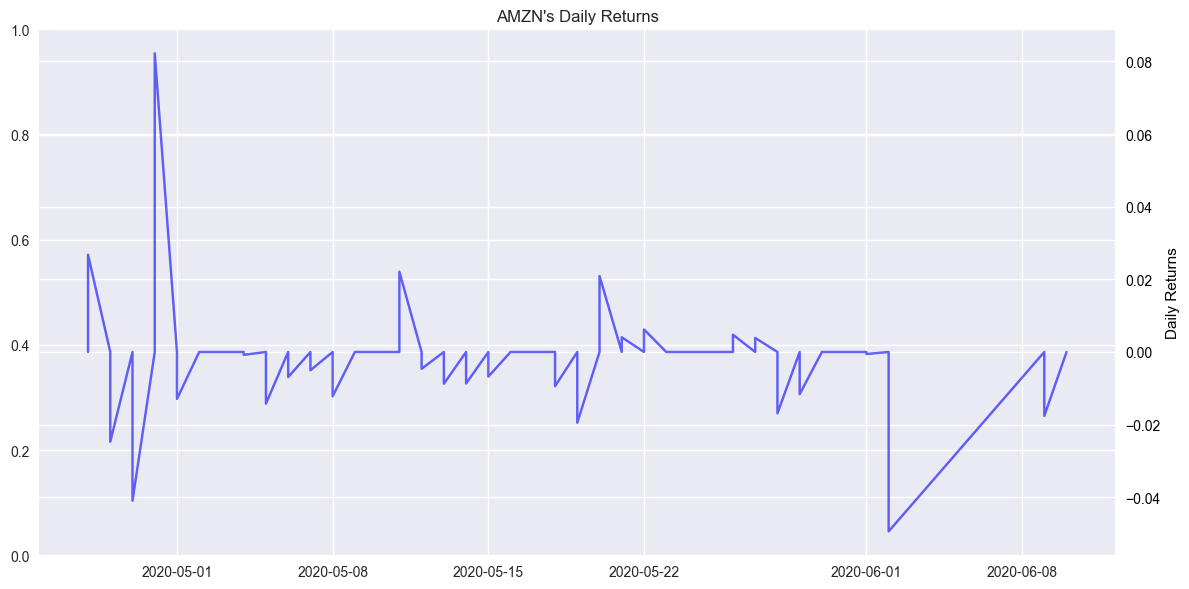

In [23]:
plotter.plot_daily_returns(data_with_daily_returns)

In [24]:
correlation_analysis = ca.CorrelationAnalysis

In [25]:
correlation_analysis.sentiment_correlation_analysis(data_with_daily_returns)

Correlation between sentiment_score and daily_returns is 0.0351
Correlation between sentiment_score and close is 0.1104


(np.float64(0.03509761120464025), np.float64(0.11042613527838904))

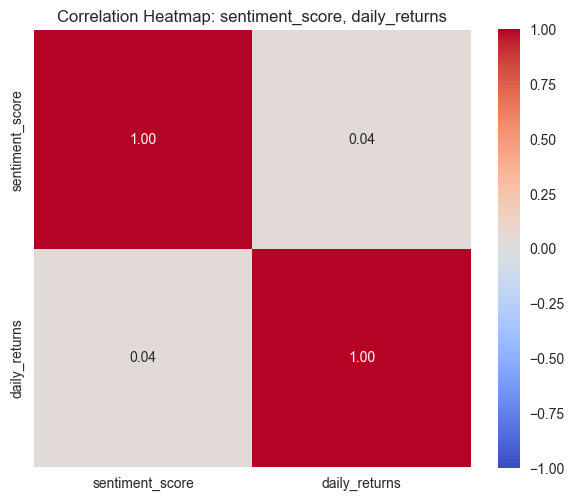

In [26]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns' ])

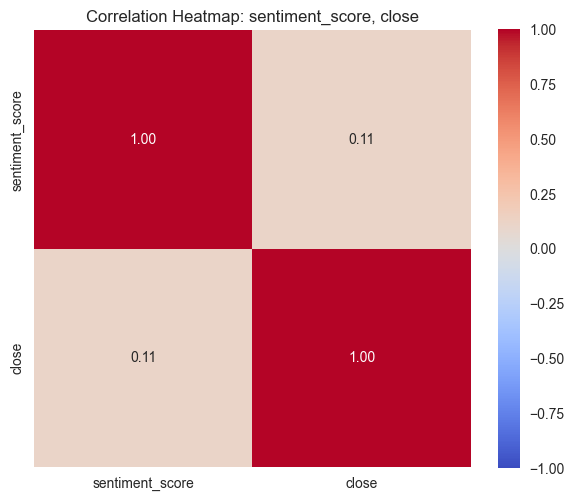

In [27]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'close' ])

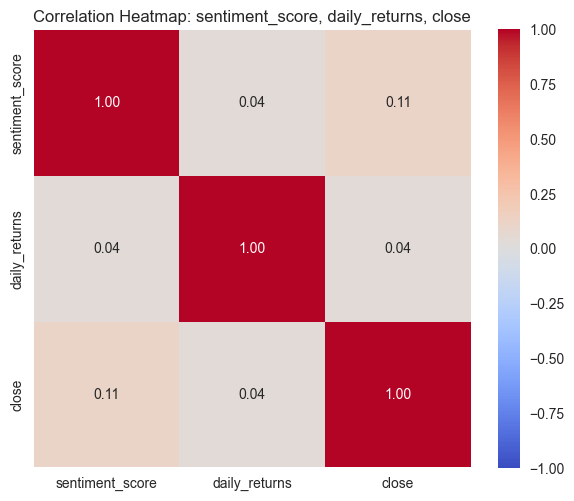

In [28]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close' ])

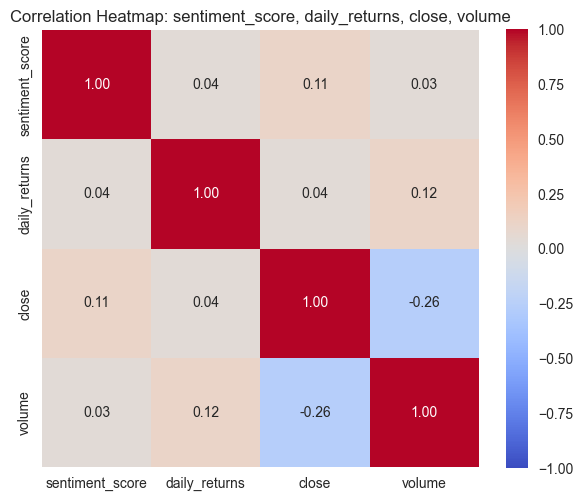

In [29]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close', 'volume' ])